# COVID severity prediction from basic patient features

This is a small side analysis for our project. I use the same patient-level file, but I only use basic clinical features for the model. Because the cohort is small, I treat the results as exploratory and compare every model with a simple baseline.


In [4]:
from pathlib import Path
import csv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import adjusted_rand_score, mean_absolute_error, mean_squared_error, r2_score, silhouette_score
from sklearn.model_selection import KFold, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans

try:
    from IPython.display import display
except ImportError:
    def display(x):
        print(x)

RANDOM_STATE = 42
BROAD_PATH = Path('data/clinical_basic_features.csv')
MEXICO_PATH = Path('data/Dataset_080620_COVID19_Mexico.csv')


## 1. Broad cohort

First I load the small cohort used by the group. Controls are removed because this part is about severity among COVID-positive patients.


In [5]:
raw = pd.read_csv(BROAD_PATH)
print('Raw shape:', raw.shape)
display(raw.head())

display(raw['WHO_Score_at_Peak'].value_counts().sort_index().to_frame('count'))
display(pd.crosstab(raw['Variant_Group'], raw['WHO_Score_at_Peak']))


Raw shape: (112, 18)


,Participant,Age,Sex,BMI,Race/Ethnicity,Diabetes,HTN,CKD,Heart_Disease,Lung_Disease,Vaccine_Status,Num_Vaccine_Doses,Variant_Group,WBC,Platelets,D_Dimer,Ferritin,WHO_Score_at_Peak
0,A_COVID19_01,65,F,31.88,Black,1,1,0.0,0,0,unvaccinated,NaN,Ancestral,9.9,245.0,581,902.0,8
1,A_COVID19_02,62,M,28.79,Black,1,1,0.0,0,0,unvaccinated,NaN,Ancestral,8.5,349.0,1974,1107.0,7
2,A_COVID19_03,49,M,27.84,American Indian/Alaska Native,0,1,0.0,0,0,unvaccinated,NaN,Ancestral,7.6,153.0,1388,956.0,8
3,A_COVID19_04,63,F,26.57,Black,1,1,1.0,1,1,unvaccinated,NaN,Ancestral,11.7,201.0,4946,1020.0,8
4,A_COVID19_05,41,F,71.91,Black,1,1,0.0,0,1,unvaccinated,NaN,Ancestral,5.0,138.0,768,737.0,5


,count
WHO_Score_at_Peak,
0,27
1,4
2,1
3,9
4,17
5,12
6,3
7,8
8,31


WHO_Score_at_Peak,0,1,2,3,4,5,6,7,8
Variant_Group,,,,,,,,,
Ancestral,0,2,0,1,2,5,2,4,16
Control,26,0,0,0,0,0,0,0,0
Delta,1,0,1,5,8,5,0,4,9
Omicron,0,2,0,3,7,2,1,0,6


COVID-positive patients: 86


,patients
High_Severity,
WHO >= 5,54
WHO < 5,32


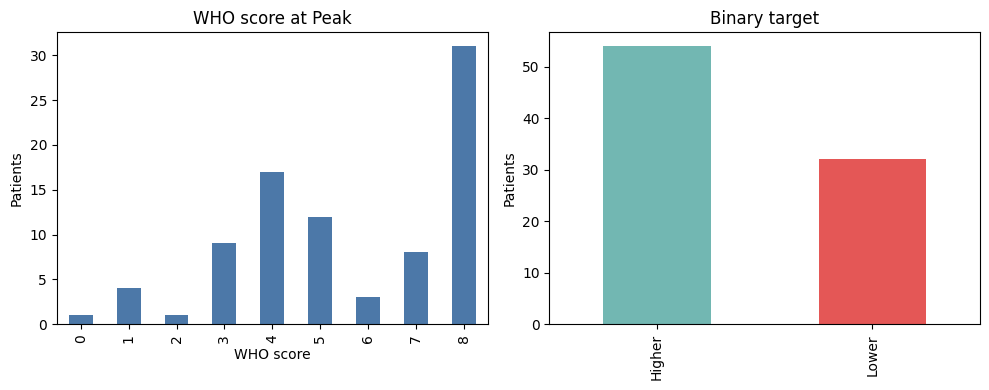

In [10]:
df = raw.copy()

for col in ['Sex', 'Race/Ethnicity', 'Vaccine_Status', 'Variant_Group']:
    df[col] = df[col].astype(str).str.strip()

def clean_number(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip().replace('<', '')
    return pd.to_numeric(text, errors='coerce')

numeric_like = ['Age', 'BMI', 'Num_Vaccine_Doses', 'WBC', 'Platelets', 'D_Dimer', 'Ferritin']
for col in numeric_like:
    df[col] = df[col].apply(clean_number)

binary_cols = ['Diabetes', 'HTN', 'CKD', 'Heart_Disease', 'Lung_Disease']
for col in binary_cols:
    df[col] = pd.to_numeric(df[col].astype(str).str.extract(r'(\d+)')[0], errors='coerce')

df.loc[df['Vaccine_Status'].eq('unvaccinated') & df['Num_Vaccine_Doses'].isna(), 'Num_Vaccine_Doses'] = 0

covid = df[df['Variant_Group'].ne('Control')].copy()
covid['High_Severity'] = (covid['WHO_Score_at_Peak'] >= 5).astype(int)

print('COVID-positive patients:', len(covid))
display(covid['High_Severity'].value_counts().rename(index={0: 'WHO < 5', 1: 'WHO >= 5'}).to_frame('patients'))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
covid['WHO_Score_at_Peak'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#4C78A8')
axes[0].set_title('WHO score at Peak')
axes[0].set_xlabel('WHO score')
axes[0].set_ylabel('Patients')

covid['High_Severity'].map({0: 'Lower', 1: 'Higher'}).value_counts().plot(kind='bar', ax=axes[1], color=['#72B7B2', '#E45756'])
axes[1].set_title('Binary target')
axes[1].set_xlabel('')
axes[1].set_ylabel('Patients')
plt.tight_layout()
plt.show()


## 2. Classification

The target is `High_Severity`, defined as WHO score >= 5. I removed `Variant_Group` from the model features so the model is based on patient/basic clinical information, not infection wave labels.


In [11]:
target = 'High_Severity'
drop_cols = ['Participant', 'WHO_Score_at_Peak', 'Variant_Group', target]
X = covid.drop(columns=[c for c in drop_cols if c in covid.columns])
y = covid[target]

numeric_features = [
    'Age', 'BMI', 'Diabetes', 'HTN', 'CKD', 'Heart_Disease', 'Lung_Disease',
    'Num_Vaccine_Doses', 'WBC', 'Platelets', 'D_Dimer', 'Ferritin'
]
numeric_features = [c for c in numeric_features if c in X.columns]
categorical_features = [c for c in ['Sex', 'Race/Ethnicity', 'Vaccine_Status'] if c in X.columns]

preprocess = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_features)
], sparse_threshold=0)

print('Features used:', X.shape[1])
print('Numeric:', numeric_features)
print('Categorical:', categorical_features)


Features used: 16
Numeric: ['Age', 'BMI', 'Diabetes', 'HTN', 'CKD', 'Heart_Disease', 'Lung_Disease', 'Num_Vaccine_Doses', 'WBC', 'Platelets', 'D_Dimer', 'Ferritin']
Categorical: ['Sex', 'Race/Ethnicity', 'Vaccine_Status']


,model,balanced_accuracy,balanced_accuracy_std,roc_auc,roc_auc_std,f1,f1_std
1,Logistic regression,0.690346,0.082676,0.763983,0.105587,0.729853,0.063436
2,Random forest,0.681515,0.104629,0.814113,0.077543,0.777810,0.047232
0,Dummy baseline,0.500000,0.000000,0.500000,0.000000,0.771301,0.018536


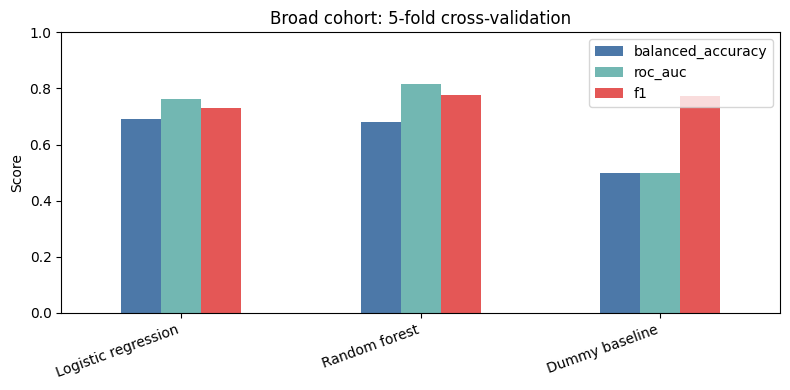

In [12]:
models = {
    'Dummy baseline': DummyClassifier(strategy='most_frequent'),
    'Logistic regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'Random forest': RandomForestClassifier(n_estimators=200, min_samples_leaf=3, class_weight='balanced', random_state=RANDOM_STATE)
}

cv_cls = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {'balanced_accuracy': 'balanced_accuracy', 'roc_auc': 'roc_auc', 'f1': 'f1'}

rows = []
for name, model in models.items():
    pipe = Pipeline([('preprocess', preprocess), ('model', model)])
    scores = cross_validate(pipe, X, y, cv=cv_cls, scoring=scoring)
    row = {'model': name}
    for metric in scoring:
        row[metric] = scores[f'test_{metric}'].mean()
        row[metric + '_std'] = scores[f'test_{metric}'].std()
    rows.append(row)

class_results = pd.DataFrame(rows).sort_values('balanced_accuracy', ascending=False)
display(class_results)

plot_df = class_results.set_index('model')[['balanced_accuracy', 'roc_auc', 'f1']]
plot_df.plot(kind='bar', figsize=(8, 4), ylim=(0, 1), color=['#4C78A8', '#72B7B2', '#E45756'])
plt.title('Broad cohort: 5-fold cross-validation')
plt.ylabel('Score')
plt.xlabel('')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


I do not choose an "optimal" probability threshold here. A 25 percent test split would have only about 22 patients, so one threshold number can look important even when it is mostly noise. The cross-validation table is a more honest result for this dataset.


In [13]:
final_lr = Pipeline([
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))
])
final_lr.fit(X, y)

coefs = final_lr.named_steps['model'].coef_[0]
try:
    feature_names = final_lr.named_steps['preprocess'].get_feature_names_out()
except AttributeError:
    feature_names = [f'feature_{i}' for i in range(len(coefs))]

coef_table = pd.DataFrame({'feature': feature_names, 'coefficient': coefs})
coef_table['abs_coefficient'] = coef_table['coefficient'].abs()
display(coef_table.sort_values('abs_coefficient', ascending=False).head(12))


,feature,coefficient,abs_coefficient
8,num__WBC,1.279063,1.279063
0,num__Age,0.967660,0.967660
18,cat__Vaccine_Status_unvaccinated,0.682532,0.682532
19,cat__Vaccine_Status_vaccinated,-0.682330,0.682330
9,num__Platelets,-0.503282,0.503282
12,cat__Sex_F,0.493409,0.493409
13,cat__Sex_M,-0.493207,0.493207
1,num__BMI,0.443212,0.443212
15,cat__Race/Ethnicity_Black,-0.424310,0.424310
16,"cat__Race/Ethnicity_White, Hispanic",0.385105,0.385105


## 3. Regression and clustering checks

These are secondary checks. Regression predicts the original WHO score. Clustering asks whether patient features naturally separate into groups that match severity.


In [14]:
y_reg = covid['WHO_Score_at_Peak']
cv_reg = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

reg_models = {
    'Mean baseline': DummyRegressor(strategy='mean'),
    'Ridge regression': Ridge(alpha=1.0),
    'Random forest regressor': RandomForestRegressor(n_estimators=200, min_samples_leaf=3, random_state=RANDOM_STATE)
}

reg_rows = []
for name, model in reg_models.items():
    pipe = Pipeline([('preprocess', preprocess), ('model', model)])
    pred = cross_val_predict(pipe, X, y_reg, cv=cv_reg)
    reg_rows.append({
        'model': name,
        'MAE': mean_absolute_error(y_reg, pred),
        'RMSE': np.sqrt(mean_squared_error(y_reg, pred)),
        'R2': r2_score(y_reg, pred)
    })

reg_results = pd.DataFrame(reg_rows).sort_values('MAE')
display(reg_results)


,model,MAE,RMSE,R2
2,Random forest regressor,1.507575,1.835090,0.330130
1,Ridge regression,1.507613,1.831997,0.332386
0,Mean baseline,2.031018,2.277623,-0.031904


In [15]:
X_cluster = preprocess.fit_transform(X)
cluster_rows = []
for k in [2, 3, 4]:
    labels = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE).fit_predict(X_cluster)
    cluster_rows.append({
        'k': k,
        'silhouette': silhouette_score(X_cluster, labels),
        'ARI_vs_severity': adjusted_rand_score(y, labels)
    })

cluster_results = pd.DataFrame(cluster_rows)
display(cluster_results)


,k,silhouette,ARI_vs_severity
0,2,0.144601,0.087260
1,3,0.124006,0.011481
2,4,0.136079,0.023987


## 4. Augmentation check

For tabular patient data, I do not treat synthetic rows as real patients. If SMOTE is available, I only use it inside the training folds as a sensitivity check and compare it with class weighting.


In [16]:
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline

    minority_n = y.value_counts().min()
    if minority_n <= 3:
        print('SMOTE skipped because the minority class is too small.')
    else:
        smote_k = min(3, minority_n - 1)
        smote_models = {
            'Class weighting': Pipeline([
                ('preprocess', preprocess),
                ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))
            ]),
            'SMOTE inside CV': ImbPipeline([
                ('preprocess', preprocess),
                ('smote', SMOTE(k_neighbors=smote_k, random_state=RANDOM_STATE)),
                ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
            ])
        }

        smote_rows = []
        for name, pipe in smote_models.items():
            scores = cross_validate(pipe, X, y, cv=cv_cls, scoring=scoring)
            smote_rows.append({
                'model': name,
                'balanced_accuracy': scores['test_balanced_accuracy'].mean(),
                'roc_auc': scores['test_roc_auc'].mean(),
                'f1': scores['test_f1'].mean()
            })
        display(pd.DataFrame(smote_rows))
except ImportError:
    print('imbalanced-learn is not installed, so I skipped the optional SMOTE check.')


,model,balanced_accuracy,roc_auc,f1
0,Class weighting,0.690346,0.763983,0.729853
1,SMOTE inside CV,0.716104,0.745628,0.749898


## Short conclusion

The broad cohort analysis is a small clinical-feature prediction test, not proof of a genetic mechanism. I avoid making artificial patients the main result. 